# Logistic Regression on MNIST — Figure 1 (left) Reproduction

Reproduction of Figure 1 (left) from *Adam: A Method for Stochastic Optimization* (Kingma & Ba, 2015).

**Experiment**: L2-regularised multi-class logistic regression on MNIST (dense features).

| Parameter | Value | Source |
|---|---|---|
| Dataset | MNIST (60 k train / 10 k test) | paper |
| Minibatch size | 128 | paper |
| Learning rate schedule | α\_t = α / √t | paper (Sec. 6.1) |
| Adam β₁, β₂, ε | 0.9, 0.999, 10⁻⁸ | paper (default) |
| SGD momentum | 0.9 | *(our choice)* |
| L2 regularisation λ | 1 × 10⁻⁴ | *(our choice)* |
| All optimizers α | grid search (see below) | paper: "dense grid, best reported" |
| Training epochs | ~45 | inferred from Fig. 1 |

### Key insight — the α / √t schedule

The paper applies a **1 / √t per-step** learning-rate decay to *all* optimizers in this experiment
(Sec. 6.1, matching the theoretical analysis of Sec. 4 / Theorem 4.1).
With 469 batches/epoch × 45 epochs ≈ 21 000 steps, the LR multiplier at the end is
≈ 1/√21000 ≈ 0.007.  If the base α is too small (e.g. 0.001), the effective LR becomes
negligible (≈ 7 × 10⁻⁶) and training stalls.

The paper says **all** hyperparameters (including α for Adam) were searched over a dense grid
and the best result is reported.  We therefore grid-search **all three optimizers**.

**Training cost** = average negative log-likelihood per sample on the current mini-batch,
smoothed over a window of 50 batches.

In [23]:
import math
import os
import copy

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ── Configuration ──
NUM_EPOCHS = 45
BATCH_SIZE = 128
WEIGHT_DECAY = 1e-4
SMOOTH_WINDOW = 300

# Grid for ALL optimizers (paper: "dense grid, best hyper-parameter setting reported")
LR_GRID = [0.001, 0.01, 0.1, 0.3, 1.0]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
train_dataset = datasets.MNIST(root='data/', train=True, download=False, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
BATCHES_PER_EPOCH = len(train_loader)
print(f'Samples: {len(train_dataset)},  Batches/epoch: {BATCHES_PER_EPOCH}')

Samples: 60000,  Batches/epoch: 469


In [15]:
def make_model():
    """Logistic regression: nn.Linear(784, 10)."""
    return nn.Linear(784, 10).to(DEVICE)


def make_scheduler(optimizer):
    """α_t = α / √t  (t = optimizer step count, 1-indexed)."""
    return torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=lambda t: 1.0 / math.sqrt(max(1, t))
    )


def train(model, optimizer, scheduler, num_epochs=NUM_EPOCHS):
    """Train model, return per-batch NLL list."""
    criterion = nn.CrossEntropyLoss()
    batch_losses = []
    model.train()
    for epoch in range(num_epochs):
        for images, labels in train_loader:
            images = images.view(images.size(0), -1).to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            batch_losses.append(loss.item())
        if (epoch + 1) % 5 == 0:
            avg = np.mean(batch_losses[-BATCHES_PER_EPOCH:])
            current_lr = scheduler.get_last_lr()[0]
            print(f'  Epoch {epoch+1:3d}/{num_epochs}  avg NLL={avg:.4f}  lr={current_lr:.6f}')
    return batch_losses


def smooth(losses, window=SMOOTH_WINDOW):
    """Running-average smoothing (mode='valid')."""
    return np.convolve(losses, np.ones(window) / window, mode='valid')


def grid_search(optimizer_class, optimizer_kwargs, lr_grid):
    """Grid search over lr_grid. Returns (best_lr, best_losses, all_results)."""
    best_lr, best_metric, best_losses = None, float('inf'), []
    all_results = {}
    for lr in lr_grid:
        print(f'\n  lr = {lr}')
        model = make_model()
        kw = copy.deepcopy(optimizer_kwargs)
        kw['lr'] = lr
        opt = optimizer_class(model.parameters(), **kw)
        sched = make_scheduler(opt)
        losses = train(model, opt, sched)
        smoothed = smooth(losses)
        tail = smoothed[-5 * BATCHES_PER_EPOCH:]
        metric = float(np.mean(tail))
        print(f'  tail-mean NLL = {metric:.4f}')
        all_results[lr] = losses
        if metric < best_metric:
            best_metric, best_lr, best_losses = metric, lr, losses
    print(f'\n  Best lr = {best_lr}  (tail-mean NLL = {best_metric:.4f})')
    return best_lr, best_losses, all_results


# Results storage
results = {}

## 1. Adam (grid search)

The paper states: *"The hyper-parameters, such as learning rate and momentum, are searched
over a dense grid and the results are reported using the best hyper-parameter setting."*
(Sec. 6).  Adam's default α = 0.001 is only a suggestion; with the α/√t per-step
schedule the effective LR decays by a factor of ~145× over 45 epochs, so the base α
must be large enough to keep the effective LR meaningful.

In [16]:
print('Grid search: Adam')
best_lr, best_losses, adam_all = grid_search(
    torch.optim.Adam,
    {'betas': (0.9, 0.999), 'eps': 1e-8, 'weight_decay': WEIGHT_DECAY},
    LR_GRID,
)
results['Adam'] = {'lr': best_lr, 'losses': best_losses}

Grid search: Adam

  lr = 0.001
  Epoch   5/45  avg NLL=0.4261  lr=0.000021
  Epoch  10/45  avg NLL=0.3700  lr=0.000015
  Epoch  15/45  avg NLL=0.3471  lr=0.000012
  Epoch  20/45  avg NLL=0.3341  lr=0.000010
  Epoch  25/45  avg NLL=0.3255  lr=0.000009
  Epoch  30/45  avg NLL=0.3191  lr=0.000008
  Epoch  35/45  avg NLL=0.3143  lr=0.000008
  Epoch  40/45  avg NLL=0.3103  lr=0.000007
  Epoch  45/45  avg NLL=0.3071  lr=0.000007
  tail-mean NLL = 0.3082

  lr = 0.01
  Epoch   5/45  avg NLL=0.2766  lr=0.000207
  Epoch  10/45  avg NLL=0.2651  lr=0.000146
  Epoch  15/45  avg NLL=0.2594  lr=0.000119
  Epoch  20/45  avg NLL=0.2561  lr=0.000103
  Epoch  25/45  avg NLL=0.2535  lr=0.000092
  Epoch  30/45  avg NLL=0.2516  lr=0.000084
  Epoch  35/45  avg NLL=0.2500  lr=0.000078
  Epoch  40/45  avg NLL=0.2488  lr=0.000073
  Epoch  45/45  avg NLL=0.2477  lr=0.000069
  tail-mean NLL = 0.2480

  lr = 0.1
  Epoch   5/45  avg NLL=0.2779  lr=0.002065
  Epoch  10/45  avg NLL=0.2576  lr=0.001460
  Epoch  15/4

## 2. SGD + Nesterov momentum (grid search)

Grid search over α ∈ LR_GRID, momentum = 0.9.

In [17]:
print('Grid search: SGDNesterov')
best_lr, best_losses, sgd_all = grid_search(
    torch.optim.SGD,
    {'momentum': 0.9, 'nesterov': True, 'weight_decay': WEIGHT_DECAY},
    LR_GRID,
)
results['SGDNesterov'] = {'lr': best_lr, 'losses': best_losses}

Grid search: SGDNesterov

  lr = 0.001
  Epoch   5/45  avg NLL=0.6235  lr=0.000021
  Epoch  10/45  avg NLL=0.5453  lr=0.000015
  Epoch  15/45  avg NLL=0.5096  lr=0.000012
  Epoch  20/45  avg NLL=0.4877  lr=0.000010
  Epoch  25/45  avg NLL=0.4721  lr=0.000009
  Epoch  30/45  avg NLL=0.4604  lr=0.000008
  Epoch  35/45  avg NLL=0.4511  lr=0.000008
  Epoch  40/45  avg NLL=0.4434  lr=0.000007
  Epoch  45/45  avg NLL=0.4368  lr=0.000007
  tail-mean NLL = 0.4396

  lr = 0.01
  Epoch   5/45  avg NLL=0.3492  lr=0.000207
  Epoch  10/45  avg NLL=0.3298  lr=0.000146
  Epoch  15/45  avg NLL=0.3204  lr=0.000119
  Epoch  20/45  avg NLL=0.3143  lr=0.000103
  Epoch  25/45  avg NLL=0.3101  lr=0.000092
  Epoch  30/45  avg NLL=0.3066  lr=0.000084
  Epoch  35/45  avg NLL=0.3039  lr=0.000078
  Epoch  40/45  avg NLL=0.3017  lr=0.000073
  Epoch  45/45  avg NLL=0.2997  lr=0.000069
  tail-mean NLL = 0.3007

  lr = 0.1
  Epoch   5/45  avg NLL=0.2760  lr=0.002065
  Epoch  10/45  avg NLL=0.2667  lr=0.001460
  Epoc

## 3. AdaGrad (grid search)

Grid search over α ∈ LR_GRID.

**Expected from the paper**: AdaGrad should converge noticeably slower than Adam and
SGDNesterov on MNIST dense features (~0.7 NLL at epoch 6, ~0.5 around epoch 27).
Every parameter is updated at every step, so AdaGrad's accumulated squared gradient
grows quickly and effectively kills the per-parameter learning rate.  Combined with
the 1/√t external schedule, AdaGrad suffers double decay.

In [18]:
print('Grid search: AdaGrad')
best_lr, best_losses, adagrad_all = grid_search(
    torch.optim.Adagrad,
    {'weight_decay': WEIGHT_DECAY},
    LR_GRID,
)
results['AdaGrad'] = {'lr': best_lr, 'losses': best_losses}

Grid search: AdaGrad

  lr = 0.001
  Epoch   5/45  avg NLL=1.5203  lr=0.000021
  Epoch  10/45  avg NLL=1.4625  lr=0.000015
  Epoch  15/45  avg NLL=1.4313  lr=0.000012
  Epoch  20/45  avg NLL=1.4101  lr=0.000010
  Epoch  25/45  avg NLL=1.3940  lr=0.000009
  Epoch  30/45  avg NLL=1.3812  lr=0.000008
  Epoch  35/45  avg NLL=1.3705  lr=0.000008
  Epoch  40/45  avg NLL=1.3614  lr=0.000007
  Epoch  45/45  avg NLL=1.3534  lr=0.000007
  tail-mean NLL = 1.3565

  lr = 0.01
  Epoch   5/45  avg NLL=0.4448  lr=0.000207
  Epoch  10/45  avg NLL=0.4271  lr=0.000146
  Epoch  15/45  avg NLL=0.4184  lr=0.000119
  Epoch  20/45  avg NLL=0.4129  lr=0.000103
  Epoch  25/45  avg NLL=0.4089  lr=0.000092
  Epoch  30/45  avg NLL=0.4058  lr=0.000084
  Epoch  35/45  avg NLL=0.4033  lr=0.000078
  Epoch  40/45  avg NLL=0.4011  lr=0.000073
  Epoch  45/45  avg NLL=0.3993  lr=0.000069
  tail-mean NLL = 0.4000

  lr = 0.1
  Epoch   5/45  avg NLL=0.4244  lr=0.002065
  Epoch  10/45  avg NLL=0.3887  lr=0.001460
  Epoch  1

## Plot: Figure 1 (left) reproduction

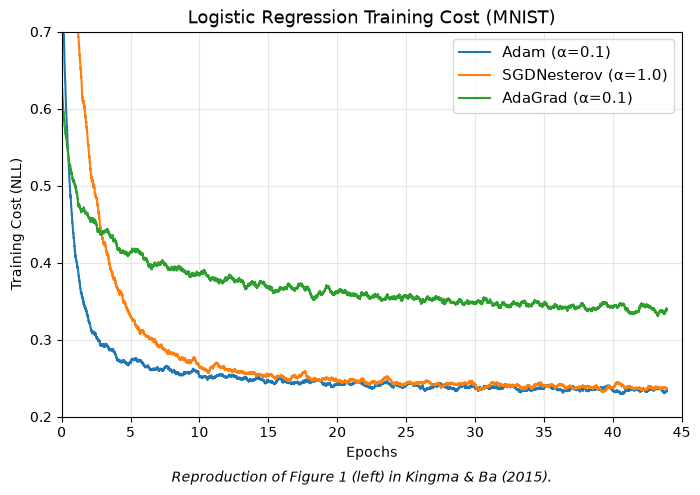

Saved to results/fig1_reproduction.png


In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {'Adam': 'tab:blue', 'SGDNesterov': 'tab:orange', 'AdaGrad': 'tab:green'}

for name in ['Adam', 'SGDNesterov', 'AdaGrad']:
    data = results[name]
    smoothed = smooth(data['losses'], 500)
    x = np.arange(len(smoothed)) / BATCHES_PER_EPOCH
    ax.plot(x, smoothed, color=colors[name], linewidth=1.5,
            label=f"{name} (\u03b1={data['lr']})")

ax.set_title('Logistic Regression Training Cost (MNIST)', fontsize=13)
ax.set_xlabel('Epochs')
ax.set_ylabel('Training Cost (NLL)')
ax.set_xlim(0, NUM_EPOCHS)
ax.set_ylim(0.20, 0.70)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

fig.text(0.5, -0.02,
         'Reproduction of Figure 1 (left) in Kingma & Ba (2015).',
         ha='center', fontsize=10, style='italic')

os.makedirs('results', exist_ok=True)
fig.savefig('results/fig1_reproduction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/fig1_reproduction.png')

## Diagnostic: all learning rates per optimizer

Each panel shows every grid-search candidate for one optimizer, so you can see
which α works best and how sensitive each method is.

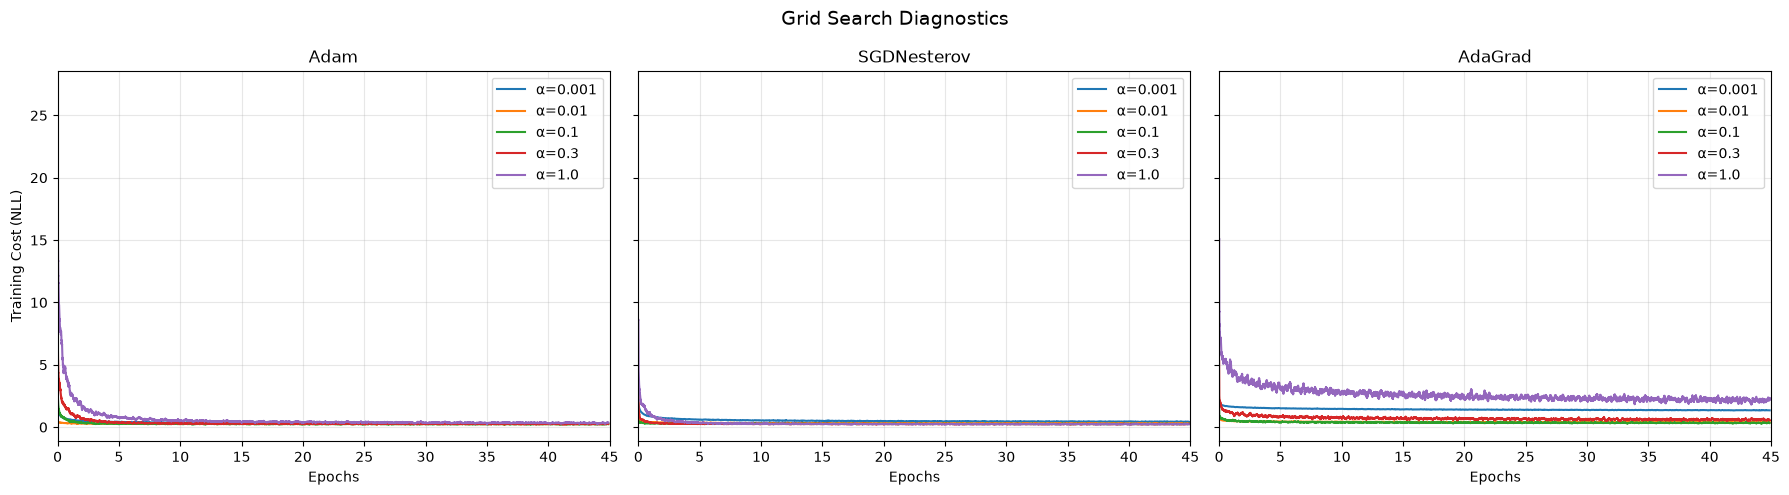

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (title, all_runs) in zip(axes, [
    ('Adam', adam_all),
    ('SGDNesterov', sgd_all),
    ('AdaGrad', adagrad_all),
]):
    for lr, losses in sorted(all_runs.items()):
        smoothed = smooth(losses)
        x = np.arange(len(smoothed)) / BATCHES_PER_EPOCH
        ax.plot(x, smoothed, linewidth=1.5, label=f'\u03b1={lr}')
    ax.set_title(title)
    ax.set_xlabel('Epochs')
    ax.set_xlim(0, NUM_EPOCHS)
    ax.legend()
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Training Cost (NLL)')
fig.suptitle('Grid Search Diagnostics', fontsize=14)
fig.tight_layout()
plt.show()